In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:

# Generate synthetic 2D data from two Gaussians
np.random.seed(42)
mu1, sigma1 = [2, 2], [[1, 0.5], [0.5, 1]]
mu2, sigma2 = [10, 2], [[1, 0], [0, 1]]

X1 = np.random.multivariate_normal(mu1, sigma1, 100)
X2 = np.random.multivariate_normal(mu2, sigma2, 50)
X = np.vstack((X1, X2))  # Combine datasets


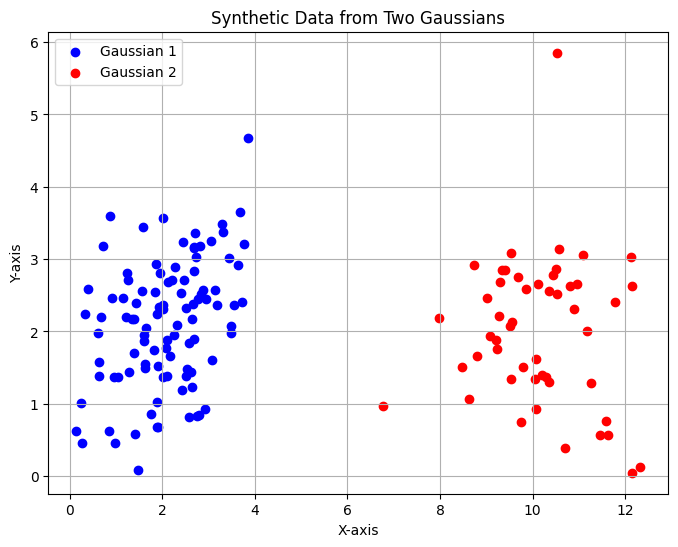

In [ ]:
# Plot the generated points
plt.figure(figsize=(8, 6))
plt.scatter(X1[:, 0], X1[:, 1], color='blue', label='Gaussian 1')
plt.scatter(X2[:, 0], X2[:, 1], color='red', label='Gaussian 2')
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.title("Synthetic Data from Two Gaussians")
plt.grid()
plt.show()

In [ ]:
X

array([[ 1.63896508,  1.50070077],
       [ 0.67757034,  2.2006002 ],
       [ 2.31985125,  2.08571429],
       [ 0.24864422,  1.01607895],
       [ 2.13529672,  2.67785677],
       [ 2.63419637,  2.16846662],
       [ 2.74709465,  0.8338144 ],
       [ 3.77496643,  3.2126789 ],
       [ 2.72001381,  3.03426115],
       [ 3.49252377,  2.08022007],
       [ 0.84359908,  0.61782278],
       [ 2.65389295,  1.22914477],
       [ 2.41598797,  2.52691056],
       [ 2.80894067,  3.18463869],
       [ 2.66601524,  2.37432149],
       [ 1.59495412,  3.4472323 ],
       [ 2.5405444 ,  1.48283348],
       [ 1.89807704,  0.67723339],
       [ 2.79895388,  0.83928376],
       [ 3.05181224,  3.24867348],
       [ 1.27478504,  1.44615332],
       [ 2.2507062 ,  1.9496025 ],
       [ 3.64035971,  2.9205155 ],
       [ 1.87036376,  2.92748599],
       [ 2.58393791,  0.82089775],
       [ 1.91187619,  1.52679391],
       [ 2.2803935 ,  2.89206979],
       [ 0.64148816,  1.57276828],
       [ 2.88138988,

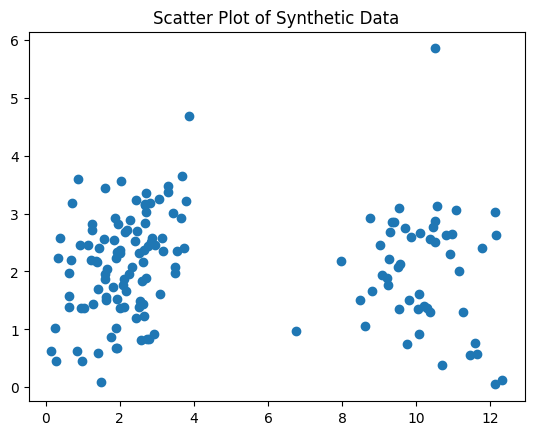

In [ ]:
# prompt: plot X

plt.scatter(X[:, 0], X[:, 1])
plt.title("Scatter Plot of Synthetic Data")
plt.show()


In [ ]:
# Initialize parameters randomly
phi = np.array([0.5, 0.5])  # Mixing coefficients
mu = np.array([[1, 1], [5, 5]])  # Random initial means
sigma = np.array([np.eye(2), np.eye(2)])  # Identity covariance matrices

In [ ]:
sigma

array([[[1., 0.],
        [0., 1.]],

       [[1., 0.],
        [0., 1.]]])

In [ ]:
from scipy.stats import multivariate_normal
def gaussian_pdf(x, mean, cov):
    return multivariate_normal.pdf(x, mean=mean, cov=cov)

In [ ]:
for j in range(2):
  print(gaussian_pdf(X, mu[j], sigma[j]).shape)

(150,)
(150,)


takes x and y values and gives p

In [ ]:
# EM Algorithm
for _ in range(1):  # Run 20 iterations
    # E-Step: Compute responsibilities w_ij
    w = np.zeros((150, 2))
    for j in range(2):
        w[:, j] = phi[j] * gaussian_pdf(X, mu[j], sigma[j])
    w /= w.sum(axis=1, keepdims=True)


    # M-Step: Update parameters
    for j in range(2):
        w_sum = np.sum(w[:, j])
        phi[j] = w_sum / 150
        mu[j] = np.sum(w[:, j][:, np.newaxis] * X, axis=0) / w_sum
        sigma[j] = (w[:, j][:, np.newaxis] * (X - mu[j])).T @ (X - mu[j]) / w_sum


w[i,j] says probability of xi coming from class j

In [ ]:
phi


array([0.59902828, 0.40097172])

In [ ]:
mu

array([[1, 2],
       [8, 2]])

In [ ]:
sigma

array([[[ 1.7455112 ,  0.33716975],
        [ 0.33716975,  0.73571877]],

       [[ 9.341707  , -0.41085019],
        [-0.41085019,  1.04653965]]])

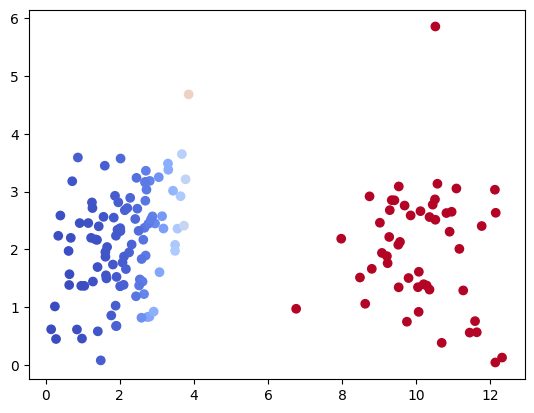

In [ ]:
# Plot the final clusters
plt.scatter(X[:, 0], X[:, 1], c=w[:, 1], cmap='coolwarm')
plt.show()

#coins

In [29]:
import numpy as np

def generate_coin_toss_samples(p_heads, num_tosses=10, num_samples=10):
    """
    Generates `num_samples` samples of `num_tosses` coin flips using a given probability of heads (`p_heads`).
    Each sample represents the number of heads observed in 10 tosses.

    Parameters:
        p_heads (float): Probability of getting heads.
        num_tosses (int): Number of tosses per sample (default is 10).
        num_samples (int): Number of samples to generate (default is 10).

    Returns:
        list: A list of integers representing the number of heads in each sample.
    """
    return list(np.random.binomial(num_tosses, p_heads, num_samples))

# Example Usage:
p_heads = 0.9  # Assume the coin has a 60% chance of landing heads
sample1 = generate_coin_toss_samples(p_heads)
print(samples)  # Output: [6, 5, 7, 4, 6, 5, 6, 8, 4, 7]

[6, 7, 6, 7, 6, 6, 4, 4, 8, 8]


In [42]:
p_heads = 0.9
sample2 = generate_coin_toss_samples(p_heads)
sample2

[9, 10, 8, 10, 10, 10, 10, 9, 10, 10]

In [43]:
sample = sample1+sample2
sample


[9, 9, 9, 9, 7, 8, 9, 10, 10, 8, 9, 10, 8, 10, 10, 10, 10, 9, 10, 10]

In [44]:
# prompt: given this sample find the pheads for first coin and second coin
#  using em algorithm, without knowing the pheads

import numpy as np

def em_coin_toss(samples, iterations=10):
    """
    Estimates the probability of heads for two coins using the EM algorithm.

    Args:
        samples: A list of integers representing the number of heads in 10 tosses for each coin.
                 Assumes the first half of the list belongs to coin 1, and the second half to coin 2.
        iterations: The number of EM iterations.

    Returns:
        A tuple containing the estimated probabilities of heads for coin 1 and coin 2.
    """
    n = len(samples)
    n_1 = n // 2  # Assuming equal number of samples for each coin

    # Initialize parameters
    p1 = 0.5
    p2 = 0.6

    for _ in range(iterations):
      #E-step
        w1 = []
        w2 = []
        for x in samples:
            prob1 = (p1**x) * ((1-p1)**(10 - x))
            prob2 = (p2**x) * ((1-p2)**(10-x))
            w1.append(prob1 / (prob1 + prob2))
            w2.append(prob2 / (prob1 + prob2))


        #M-step
        p1 = sum(w1[:n_1] * np.array(samples[:n_1])) / sum(w1[:n_1]*10)
        p2 = sum(w2[n_1:] * np.array(samples[n_1:])) / sum(w2[n_1:]*10)

    return p1, p2


# Example usage (assuming you have the 'sample' list from your original code):

p1_est, p2_est = em_coin_toss(sample)
print(f"Estimated probability of heads for coin 1: {p1_est}")
print(f"Estimated probability of heads for coin 2: {p2_est}")


Estimated probability of heads for coin 1: 0.8542765011875322
Estimated probability of heads for coin 2: 0.9974432962838116
